In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
np.random.seed(42)

hours = np.arange(1, 1001)

temperature = np.random.randint(20, 45, 1000)
humidity = np.random.randint(30, 90, 1000)

load = (
    100
    + temperature * 3
    + humidity * 0.5
    + np.random.normal(0, 10, 1000)
)

df = pd.DataFrame({
    "Temperature": temperature,
    "Humidity": humidity,
    "Load": load
})

df.head()

,Temperature,Humidity,Load
0,26,35,189.910782
1,39,35,238.272119
2,34,84,259.655240
3,30,77,227.842497
4,27,33,191.948005


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  1000 non-null   int32  
 1   Humidity     1000 non-null   int32  
 2   Load         1000 non-null   float64
dtypes: float64(1), int32(2)
memory usage: 15.8 KB


,Temperature,Humidity,Load
count,1000.000000,1000.000000,1000.000000
mean,31.991000,59.775000,226.439744
std,7.443946,17.203149,26.199024
min,20.000000,30.000000,163.960789
25%,25.000000,45.000000,206.539383
50%,32.000000,60.000000,227.210527
75%,38.250000,74.000000,246.649937
max,44.000000,89.000000,292.391168


In [5]:
df.isnull().sum()

Temperature    0
Humidity       0
Load           0
dtype: int64

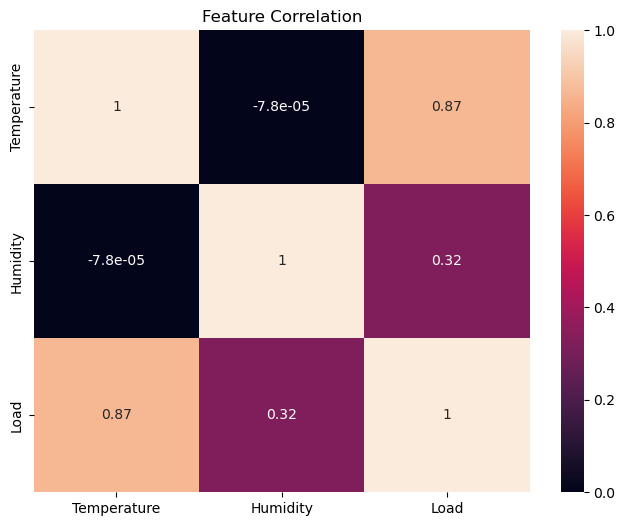

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()


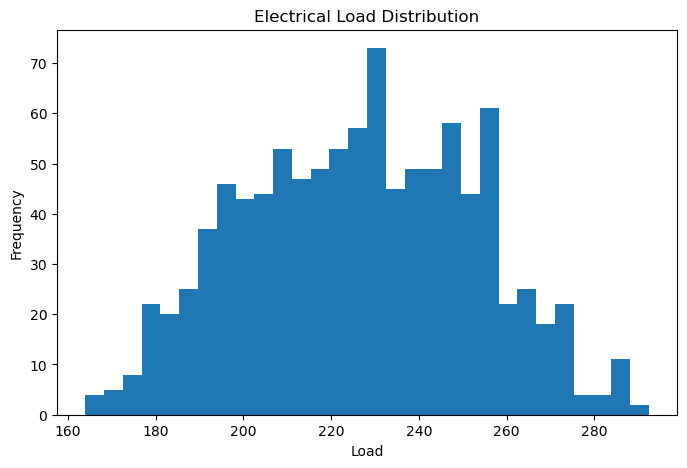

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["Load"], bins=30)
plt.title("Electrical Load Distribution")
plt.xlabel("Load")
plt.ylabel("Frequency")
plt.show()

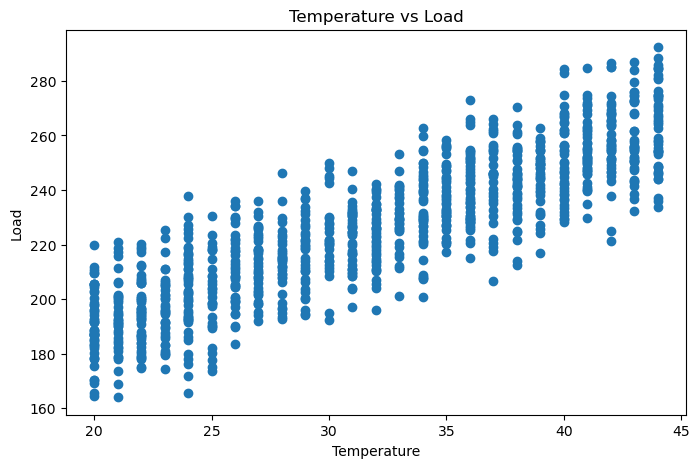

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df["Temperature"], df["Load"])
plt.title("Temperature vs Load")
plt.xlabel("Temperature")
plt.ylabel("Load")
plt.show()

In [9]:
X = df[["Temperature", "Humidity"]]
y = df["Load"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
predictions = model.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae,2))
print("R2 Score:", round(r2,2))

MAE: 10.23
R2 Score: 0.78


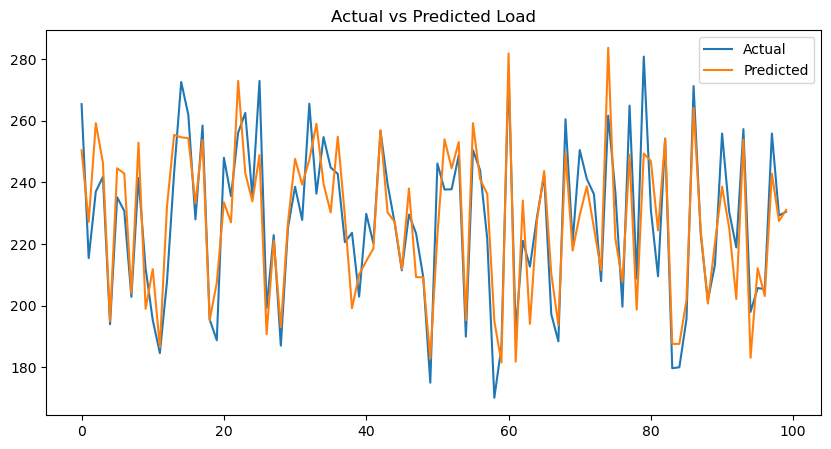

In [14]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(predictions[:100], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Load")
plt.show()

In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(importance)


       Feature  Importance
0  Temperature    0.803219
1     Humidity    0.196781


In [16]:
future_data = pd.DataFrame({
    "Temperature":[38],
    "Humidity":[65]
})

future_load = model.predict(future_data)

print("Predicted Load =", round(future_load[0],2))

Predicted Load = 242.81


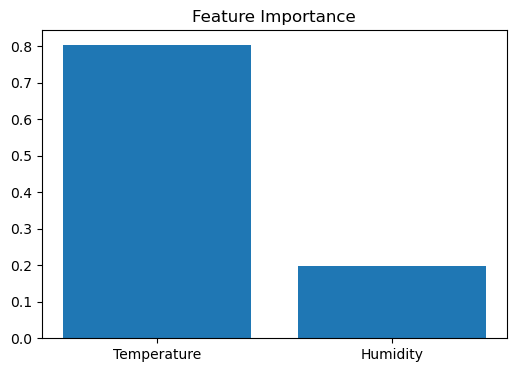

In [17]:
plt.figure(figsize=(6,4))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")
plt.show()